# Практика 5. Шкали вимірювання і частотний розподіл

Мета: класифікувати змінні за шкалою вимірювання, побудувати варіаційний ряд, частотну таблицю та гістограми, а також пов'язати міри положення з типом шкали.

**Інструкція:** у клітинці нижче змініть `city`, якщо ваш номер варіанта відповідає іншому місту. За замовчуванням обрано Київ, варіант 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

months = ['Січень', 'Лютий', 'Березень', 'Квітень', 'Травень', 'Червень', 'Липень', 'Серпень', 'Вересень', 'Жовтень', 'Листопад', 'Грудень']
data = {
    'Київ': [47, 44, 38, 43, 60, 78, 88, 70, 48, 41, 47, 50],
    'Львів': [40, 38, 40, 55, 80, 95, 100, 85, 54, 54, 48, 42],
    'Одеса': [30, 28, 25, 28, 35, 45, 40, 35, 30, 28, 35, 33],
    'Харків': [38, 35, 32, 38, 50, 65, 70, 55, 40, 35, 40, 42],
    'Дніпро': [35, 32, 28, 33, 45, 58, 55, 45, 33, 30, 36, 38],
    'Чернігів': [42, 38, 35, 40, 55, 72, 80, 65, 45, 40, 44, 46],
    'Івано-Франківськ': [45, 42, 45, 60, 90, 105, 110, 95, 60, 50, 52, 48],
    'Полтава': [37, 34, 31, 37, 48, 62, 68, 52, 38, 34, 39, 41],
    'Суми': [40, 36, 33, 39, 52, 68, 75, 58, 42, 37, 42, 44],
    'Ужгород': [48, 45, 48, 62, 88, 100, 105, 90, 58, 52, 55, 50]
}
city = 'Київ'
if city not in data:
    raise ValueError(f'Невідоме місто: {city}. Оберіть одне з: {list(data)}')

rain = pd.Series(data[city], index=months, name='Опади, мм')
print(f'Варіант: {list(data).index(city) + 1}; місто: {city}')
display(rain.to_frame())

Варіант: 1; місто: Київ


,"Опади, мм"
Січень,47
Лютий,44
Березень,38
Квітень,43
Травень,60
Червень,78
Липень,88
Серпень,70
Вересень,48
Жовтень,41


## Завдання 1. Класифікація змінних за шкалою вимірювання

- **Місто — номінальна шкала.** Це назви категорій без природного порядку та змістовних числових відстаней. Для міста коректна міра положення — лише **мода**.
- **Номер місяця — порядкова шкала** у цьому аналізі: місяці мають природний порядок, але число 1 не є природним нулем, а різниця між номерами не є вимірюванням кількості певної властивості. Водночас можна захищати й інтервальну інтерпретацію, якщо вважати календарні проміжки рівними; тоді треба чітко зазначити, що початок відліку умовний.
- **Кількість опадів — відносна шкала.** Є природний нуль (0 мм означає відсутність опадів), рівні різниці та змістовні відношення: 80 мм удвічі більше за 40 мм. Для неї коректні **середнє, медіана й мода**.

## Завдання 2. Варіаційний ряд і частотна таблиця

In [2]:
variation_series = np.sort(rain.to_numpy())
print('Варіаційний ряд:')
print(variation_series)

# Чотири рівні за шириною інтервали; останній інтервал включає праву межу.
edges = np.linspace(rain.min(), rain.max(), 5)
intervals = pd.cut(rain, bins=edges, include_lowest=True, duplicates='drop')
frequency = intervals.value_counts(sort=False)
frequency_table = pd.DataFrame({
    'Абсолютна частота': frequency,
    'Відносна частота, %': (frequency / len(rain) * 100).round(1),
    'Накопичена частота': frequency.cumsum()
})
display(frequency_table)
third_boundary = edges[3]
third_share = (rain <= third_boundary).mean() * 100
print(f'Межа третього інтервалу: {third_boundary:.2f} мм')
print(f'Частка місяців із опадами не більшими за цю межу: {third_share:.1f}%')

Варіаційний ряд:
[38 41 43 44 47 47 48 50 60 70 78 88]


,Абсолютна частота,"Відносна частота, %",Накопичена частота
"Опади, мм",,,
"(37.999, 50.5]",8,66.7,8
"(50.5, 63.0]",1,8.3,9
"(63.0, 75.5]",1,8.3,10
"(75.5, 88.0]",2,16.7,12


Межа третього інтервалу: 75.50 мм
Частка місяців із опадами не більшими за цю межу: 83.3%


**Інтерпретація:** накопичена частота на межі третього інтервалу показує, яка кількість із 12 місяців, а у відсотках яка частка року, має опади не більші за цю межу. Для обраного міста це значення виведене попередньою клітинкою.

## Завдання 3. Гістограма

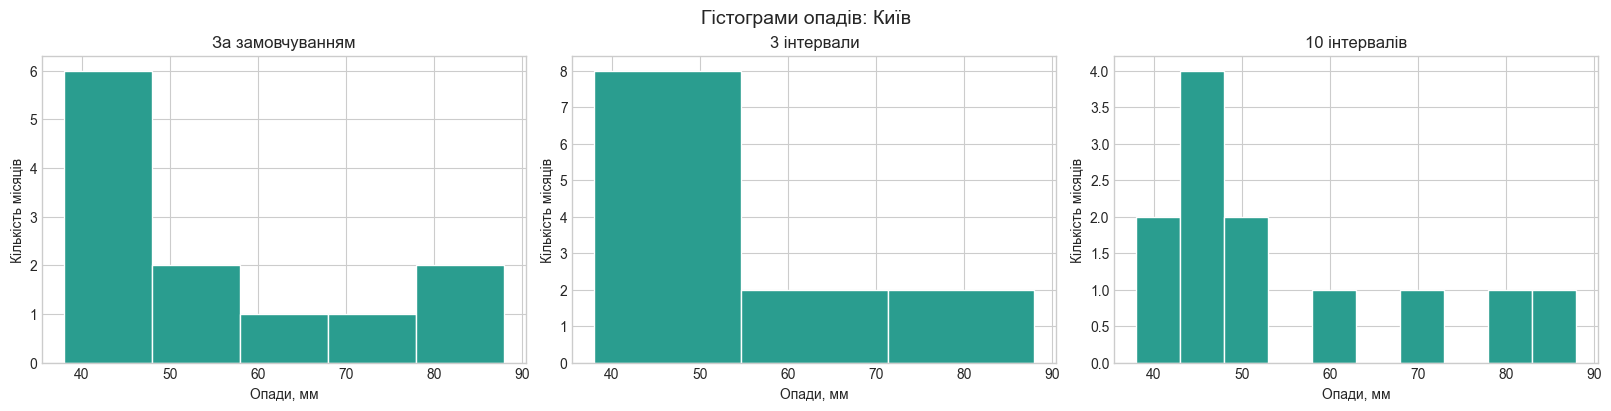

Правило √n: √12 ≈ 3.46, орієнтовно 4 інтервали(ів).
Правило Стерджеса: 1 + log2(12) ≈ 4.58, орієнтовно 5 інтервали(ів).


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for ax, bins, title in zip(axes, ['auto', 3, 10], ['За замовчуванням', '3 інтервали', '10 інтервалів']):
    ax.hist(rain, bins=bins, edgecolor='white', color='#2a9d8f')
    ax.set_title(title)
    ax.set_xlabel('Опади, мм')
    ax.set_ylabel('Кількість місяців')
fig.suptitle(f'Гістограми опадів: {city}', fontsize=14)
plt.show()

n = len(rain)
sqrt_bins = int(np.ceil(np.sqrt(n)))
sturges_bins = int(np.ceil(1 + np.log2(n)))
print(f'Правило √n: √{n} ≈ {np.sqrt(n):.2f}, орієнтовно {sqrt_bins} інтервали(ів).')
print(f'Правило Стерджеса: 1 + log2({n}) ≈ {1 + np.log2(n):.2f}, орієнтовно {sturges_bins} інтервали(ів).')

Для `n = 12` обидва правила дають приблизно 4 інтервали. Гістограма з 3 інтервалами добре показує загальну форму, але може приховати деталі; з 10 інтервалами є надмірно подрібненою для лише 12 спостережень. Найкращим компромісом є гістограма за замовчуванням або близька до рекомендацій правил, приблизно на 4 інтервали.

## Завдання 4. Міри положення й квантилі

In [4]:
mode_values = rain.mode().tolist()
statistics = pd.Series({
    'Середнє, мм': rain.mean(),
    'Медіана, мм': rain.median(),
    'Q1, мм': rain.quantile(0.25),
    'Q3, мм': rain.quantile(0.75)
})
display(statistics.round(2).to_frame('Значення'))
print('Мода, мм:', mode_values)
difference = rain.mean() - rain.median()
print(f'Різниця між середнім і медіаною: {difference:.2f} мм')

,Значення
"Середнє, мм",54.50
"Медіана, мм",47.50
"Q1, мм",43.75
"Q3, мм",62.50


Мода, мм: [47]
Різниця між середнім і медіаною: 7.00 мм


Середнє порівнюємо з медіаною: якщо середнє помітно більше, це може свідчити про правосторонню асиметрію, коли кілька дуже вологих місяців підтягують середнє вгору. Для конкретного міста висновок робимо за виведеними значеннями та величиною їх різниці. Якщо значення близькі, вираженої асиметрії за цим простим порівнянням не видно.

## Завдання 5. Зв'язок зі шкалою вимірювання

Кількість опадів належить до відносної шкали: має справжній нуль, рівні одиниці вимірювання та змістовні відношення. Тому для неї мають сенс середнє як арифметичний центр, медіана як центральне впорядковане значення і мода як найчастіше значення. Місто є номінальною категорією: числові коди міст були б лише мітками, тому їхнє середнє або медіана не мали б змісту. Для міста коректною мірою положення є лише мода.

### Короткі відповіді

1. **Чому середнє некоректне для міста?** Кодування назв числами не створює числової властивості: заміна кодів змінить середнє, хоча самі міста залишаться тими самими.
2. **Чому номер місяця класифікують неоднозначно?** Він має порядок і рівні календарні проміжки, але не має природного нульового місяця. Тому це можна трактувати як порядкову шкалу або, за спеціальним календарним припущенням, як інтервальну; висновок треба обґрунтувати.
3. **Чому потрібна гістограма?** Майже всі 12 значень опадів різні, тому стовпчикова діаграма за кожним окремим значенням дала б багато одиничних стовпців і погано показала форму розподілу. Гістограма об'єднує значення в інтервали.
4. **Що означає накопичена частота третього інтервалу?** Це кількість або частка місяців, у яких опади не перевищують верхню межу третього інтервалу.

## Підсумок

У роботі класифіковано місто, номер місяця та кількість опадів за шкалами вимірювання; побудовано варіаційний ряд і інтервальну частотну таблицю; порівняно гістограми з різною кількістю інтервалів; обчислено середнє, медіану, моду та квартилі. Результати інтерпретовано з урахуванням того, що для змінної відносної шкали допустимі всі три основні міри положення.